#### Behavior surrounding SEDS set changes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from scipy.ndimage import gaussian_filter1d

import os
import sys

#os.chdir(os.path.split(os.getcwd())[0])


Test if incongruent trials are below chance following a rule switch

In [5]:
# pool a bunch of sessions
fnames = [
    os.path.join(root,r"OtherData\John\EXPERIMENTS\LAYER6\Panneuronal\T30_M_LeftPFC_L6Chr_PFCgcamp6f\FOV3\SEDS_day3_FOV3_noProbe_optoRec"),
    os.path.join(root,r"OtherData\John\EXPERIMENTS\LAYER6\Panneuronal\T30_M_LeftPFC_L6Chr_PFCgcamp6f\FOV3\SEDS_day4_FOV3_noProbe_optoRec"),
    os.path.join(root,r"OtherData\John\EXPERIMENTS\LAYER6\Panneuronal\T30_M_LeftPFC_L6Chr_PFCgcamp6f\FOV3\SEDS_day6_FOV3_probe_noOpto"),
    os.path.join(root,r"OtherData\John\EXPERIMENTS\LAYER6\Panneuronal\T30_M_LeftPFC_L6Chr_PFCgcamp6f\FOV3\SEDS_day8_FOV3_probe_noOpto")
    ]

bdata = dict()
for i in fnames:
    sessname = os.path.split(i)[-1] # get session name
    bpath = os.path.join(i, "puttyTable.csv") # join .csv file to path
    bdata[sessname]=pd.read_csv(bpath) # read data
sessions = list(bdata.keys())
#bdata[sessions[0]]

Incongruent trials are trials where the stimulus and irrelevant stimulus are opposite

In [6]:
incog_trials = dict(); cong_trials = dict()
for i in sessions:
    incog_trials[i]=bdata[i][bdata[i]['stim'] != bdata[i]['irrel']]
    cong_trials[i]=bdata[i][bdata[i]['stim']==bdata[i]['irrel']]

Find cases where the animal did not lick left and right, yet still got the incongruent trial correct

In [7]:
sessions

['SEDS_day3_FOV3_noProbe_optoRec',
 'SEDS_day4_FOV3_noProbe_optoRec',
 'SEDS_day6_FOV3_probe_noOpto',
 'SEDS_day8_FOV3_probe_noOpto']

In [7]:
#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', None)
incog_trials[sessions[0]]
#cong_trials[sessions[0]]

,n,blknum,iti,setID,trialLR,stim,irrel,lnL,lnR,rt,resp,corr,rAL,rAR,rANG,rA,H2O,OPTO
0,1,1,0,-1,1,1,-1,0,0,28,1,1,0.0,0.1,1,0.03,4,0
3,4,1,8643,-1,-1,-1,1,7,8,33,1,1,0.1,0.2,1,0.10,12,0
4,5,1,8449,-1,-1,-1,1,8,6,1,1,1,0.2,0.2,1,0.13,16,0
5,6,1,8228,-1,1,1,-1,12,1,16,1,0,0.2,0.2,1,0.13,16,1
8,9,1,8140,-1,-1,-1,1,12,0,108,1,1,0.5,0.2,1,0.23,28,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,392,8,8400,1,1,1,-1,2,8,0,1,1,0.5,0.2,1,0.23,1160,0
392,393,8,9376,1,-1,-1,1,1,13,1,1,0,0.5,0.2,1,0.23,1160,1
394,395,8,8544,1,-1,-1,1,1,14,90,1,0,0.6,0.2,1,0.27,1164,0
395,396,8,8299,1,-1,-1,1,6,8,0,1,1,0.7,0.2,1,0.30,1168,1


In [8]:
dualLickIncog = []; dualLickCong = []
for i in sessions:
    dualLickIncog.append(len(incog_trials[i][(incog_trials[i]['lnR'] > 0) & (incog_trials[i]['lnL'] > 0) & (incog_trials[i]['corr']==1)])/len(incog_trials[i]))
    dualLickCong.append(len(cong_trials[i][(cong_trials[i]['lnR'] > 0) & (cong_trials[i]['lnL'] > 0) & (cong_trials[i]['corr']==1)])/len(cong_trials[i]))


`dualLickCong` is the proportion of times where the mouse licks both left and right on congruent trials and received reward

`dualLickIncog` is the proportion of times where the mouse licks both left and right on incongruent trials and received reward

In [12]:
dualLickCong

[0.34146341463414637,
 0.2237442922374429,
 0.4307692307692308,
 0.11557788944723618]

In [13]:
dualLickIncog

[0.32663316582914576,
 0.2694300518134715,
 0.3588235294117647,
 0.31976744186046513]

In [9]:
lickBothCorrect = []
for i in sessions:
    lickBothCorrect.append(len(bdata[i][(bdata[i]['lnR'] > 0) & (bdata[i]['lnL'] > 0) & (bdata[i]['corr']==1)])/len(bdata[i]))

In [26]:
lickBothCorrect

[0.3341584158415842,
 0.24514563106796117,
 0.3972602739726027,
 0.21024258760107817]

In [10]:
lickBoth = []
for i in sessions:
    lickBoth.append(len(bdata[i][(bdata[i]['lnR'] > 0) & (bdata[i]['lnL'] > 0)])/len(bdata[i]))

In [28]:
lickBoth

[0.5346534653465347,
 0.3932038834951456,
 0.5232876712328767,
 0.29649595687331537]

Performance on congruent trials around blocks

In [12]:
def performancePlot(behdata, window_size):

    # calculate a running average
    rAvg = running_average(behdata['corr'], window_size=window_size)

    # smooth result
    smAvg = gaussian_filter1d(rAvg, sigma=2)

    # get block switch indices
    blkswitch = np.where(np.diff(behdata['blknum'])==1)[0]+1
    blkswitch_corrected = blkswitch-window_size

    # new trialcount x axis
    trialX = np.linspace(window_size, len(behdata['corr'])-(window_size-1), len(behdata['corr'])-(window_size-1), dtype=int)

    # generate figure
    plt.plot(trialX, smAvg, color = 'k')
    plt.plot(trialX, rAvg, color = 'gray', linewidth=.5, alpha = 1)

    for i in blkswitch_corrected:
        plt.axvline(x=i, color='r', linestyle='--', label='Vertical Line')

    plt.ylabel("Proportion Correct")
    plt.xlabel("Trial")

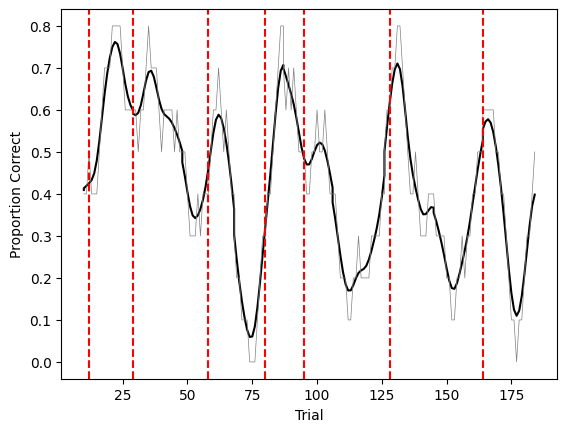

In [17]:
performancePlot(behdata=incog_trials[sessions[1]],window_size=5)